<a href="https://www.kaggle.com/code/allasamoilenko/fruit-classification?scriptVersionId=230781204" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
root_dir = '/kaggle/input/fruit-recognition/train/train'

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),  
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomRotation(degrees=15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.ToTensor(),  
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  
])

val_transforms = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor(), 
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
])

train_dataset = datasets.ImageFolder(root_dir, transform=train_transforms)

train_ratio = 0.8
train_size = int(train_ratio * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

val_data.dataset.transform = val_transforms

In [6]:
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [8]:
num_classes = len(train_dataset.classes)
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

Epoch [1/10], Loss: 0.2230
Epoch [2/10], Loss: 0.0053
Epoch [3/10], Loss: 0.0002
Epoch [4/10], Loss: 0.0000
Epoch [5/10], Loss: 0.0000
Epoch [6/10], Loss: 0.0000
Epoch [7/10], Loss: 0.0000
Epoch [8/10], Loss: 0.0000
Epoch [9/10], Loss: 0.0000
Epoch [10/10], Loss: 0.0000


In [10]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

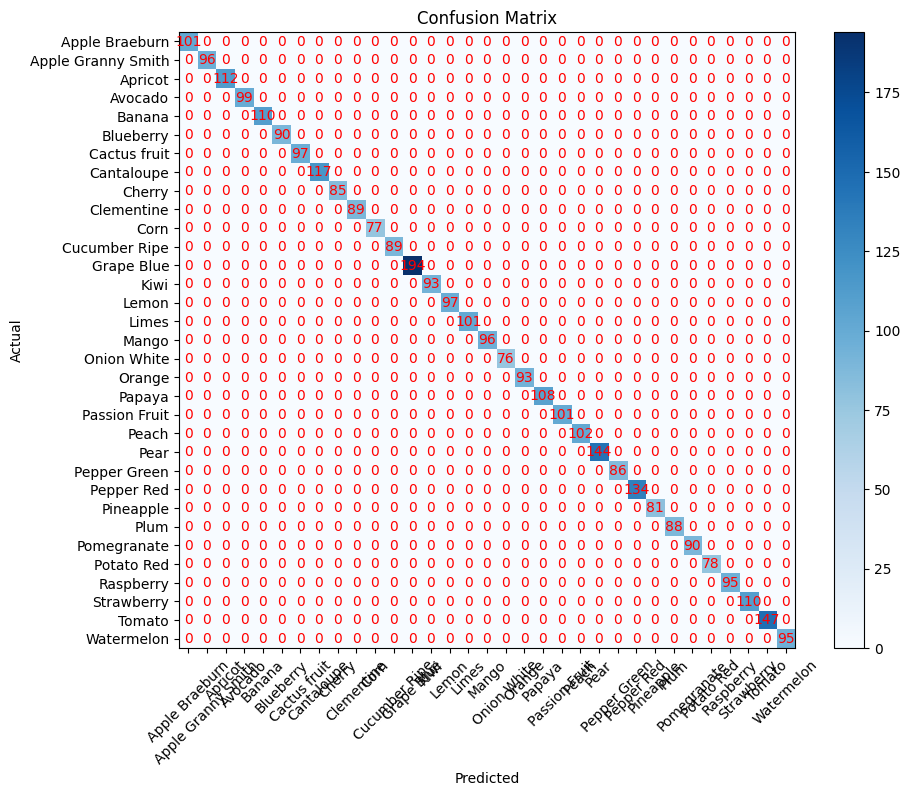

                    precision    recall  f1-score   support

    Apple Braeburn       1.00      1.00      1.00       101
Apple Granny Smith       1.00      1.00      1.00        96
           Apricot       1.00      1.00      1.00       112
           Avocado       1.00      1.00      1.00        99
            Banana       1.00      1.00      1.00       110
         Blueberry       1.00      1.00      1.00        90
      Cactus fruit       1.00      1.00      1.00        97
        Cantaloupe       1.00      1.00      1.00       117
            Cherry       1.00      1.00      1.00        85
        Clementine       1.00      1.00      1.00        89
              Corn       1.00      1.00      1.00        77
     Cucumber Ripe       1.00      1.00      1.00        89
        Grape Blue       1.00      1.00      1.00       194
              Kiwi       1.00      1.00      1.00        93
             Lemon       1.00      1.00      1.00        97
             Limes       1.00      1.00

In [11]:
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, cmap='Blues')
plt.colorbar()
plt.xticks(np.arange(len(train_dataset.classes)), train_dataset.classes, rotation=45)
plt.yticks(np.arange(len(train_dataset.classes)), train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
for i in range(len(train_dataset.classes)):
    for j in range(len(train_dataset.classes)):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='red')
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

In [12]:
torch.save(model.state_dict(), 'fruit_recognition_model.pth')